# 03 — Avaliação do modelo gerador

A prova pede para *"avaliar a qualidade e originalidade do conteúdo gerado,
ajustando o modelo e os parâmetros conforme necessário"*. Um número só não
responde isso, porque as propriedades desejadas competem entre si.

Este notebook mede quatro eixos e mostra onde eles se contradizem:

| Eixo | Pergunta | Métrica |
|---|---|---|
| **Qualidade** | O modelo aprendeu a língua das receitas? | perplexidade na validação |
| **Originalidade** | Está criando ou recitando de cor? | sobreposição de 5-gramas com o treino |
| **Diversidade** | Gera coisas diferentes entre si? | distinct-2, Jaccard entre amostras |
| **Estrutura** | A saída é uma receita utilizável? | taxa de gerações bem-formadas |

O ponto central: **baixar a temperatura melhora a estrutura e piora a
originalidade**. A escolha dos parâmetros do playground sai dessa fronteira, não
de preferência pessoal.

---

> **Onde rodar:** este notebook gera centenas de receitas. Numa GPU leva poucos
> minutos; em CPU, bastante mais. Rodando no Colab, execute antes a célula de
> setup logo abaixo.

## Setup

In [1]:
# --- Só no Google Colab: descomente este bloco ---
!pip install -q "transformers>=5.0" "datasets>=4.0" accelerate
!git clone -q https://github.com/denisevitoriano/tech_challenge_fase_04.git /content/projeto
import sys, os; sys.path.insert(0, "/content/projeto/src"); os.chdir("/content/projeto")

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from tech_challenge_fase_04.avaliacao.metricas import (
    distinct_n, indexar_ngramas, maior_trecho_copiado, perplexidade,
    repeticao_entre_amostras, taxa_de_copia, tokenizar_palavras, validade_estrutural,
)
from tech_challenge_fase_04.avaliacao.visual import (
    AQUA, AZUL, LARANJA, TINTA_SECUNDARIA, aplicar_estilo, rotular_barras,
)
from tech_challenge_fase_04.dados.corpus import FIM, INICIO
from tech_challenge_fase_04.modelo import DIRETORIO_MODELO, MODELO_BASE

aplicar_estilo()

# Modelo publicado no Hub. Use DIRETORIO_MODELO para avaliar um treino local.
MODELO_AJUSTADO = "denisevitoriano/receitas-gpt2-pt"

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURAS = RAIZ / "reports" / "figures"
FIGURAS.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("dispositivo:", DEVICE)

treino = [json.loads(l) for l in (RAIZ / "data/processed/treino.jsonl").open(encoding="utf-8")]
validacao = [json.loads(l) for l in (RAIZ / "data/processed/validacao.jsonl").open(encoding="utf-8")]
print(f"{len(treino)} exemplos de treino | {len(validacao)} de validação")

dispositivo: cuda
4504 exemplos de treino | 508 de validação


## 1. Qualidade — perplexidade antes e depois

Perplexidade é a "surpresa" média do modelo diante de texto que ele nunca viu:
quanto menor, melhor ele previu. Isoladamente o número não diz muita coisa —
o que informa é a **comparação** entre o modelo base e o ajustado, sobre os
mesmos textos.

Os marcadores `<|receita|>` e `<|fim|>` são removidos da avaliação: o modelo
base nunca os viu, e penalizá-lo por isso mediria o vocabulário adicionado, não
a capacidade de escrever receitas.

In [3]:
def sem_marcadores(exemplos):
    return [e["texto"].replace(INICIO, "").replace(FIM, "").strip() for e in exemplos]

textos_validacao = sem_marcadores(validacao)

tok_base = AutoTokenizer.from_pretrained(MODELO_BASE)
mod_base = AutoModelForCausalLM.from_pretrained(MODELO_BASE).to(DEVICE)
ppl_base = perplexidade(mod_base, tok_base, textos_validacao)

del mod_base
if DEVICE == "cuda":
    torch.cuda.empty_cache()

tok = AutoTokenizer.from_pretrained(MODELO_AJUSTADO)
mod = AutoModelForCausalLM.from_pretrained(MODELO_AJUSTADO).to(DEVICE)
ppl_ajustado = perplexidade(mod, tok, textos_validacao)

print(f"base:     {ppl_base:8.2f}")
print(f"ajustado: {ppl_ajustado:8.2f}")
print(f"redução:  {(1 - ppl_ajustado / ppl_base):8.1%}")

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


base:        37.10
ajustado:     5.14
redução:     86.1%


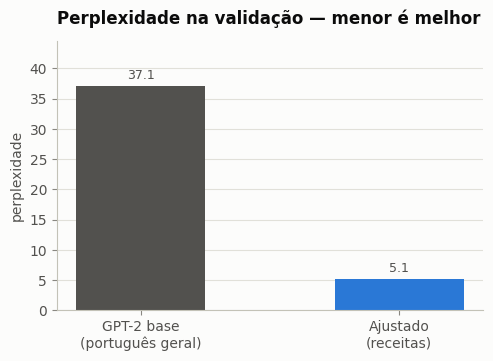

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
barras = ax.bar(
    ["GPT-2 base\n(português geral)", "Ajustado\n(receitas)"],
    [ppl_base, ppl_ajustado],
    color=[TINTA_SECUNDARIA, AZUL],
    width=0.5,
)
rotular_barras(ax, formato="{:.1f}")
ax.set_title("Perplexidade na validação — menor é melhor")
ax.set_ylabel("perplexidade")
ax.set_ylim(0, max(ppl_base, ppl_ajustado) * 1.2)
plt.savefig(FIGURAS / "03_perplexidade.png")
plt.show()

## 2. Gerar as amostras para avaliação

Uma varredura de temperatura, mantendo tudo o mais fixo. Cada temperatura
recebe o mesmo conjunto de prompts, para que a comparação isole o efeito do
parâmetro.

In [5]:
import random

from tech_challenge_fase_04.modelo.geracao import carregar, gerar_de_prompt
from tech_challenge_fase_04.dados.corpus import prefixo_livre

# Reaproveita o modelo já carregado no cache do módulo de geração.
carregar.cache_clear()
_ = carregar(MODELO_AJUSTADO, DEVICE)

receitas_originais = [json.loads(l) for l in (RAIZ / "data/processed/receitas.jsonl").open(encoding="utf-8")]
categorias = [c for c, _ in pd.Series([r["categoria"] for r in receitas_originais]).value_counts().head(10).items()]

TEMPERATURAS = [0.5, 0.7, 0.9, 1.1, 1.3]
AMOSTRAS_POR_TEMPERATURA = 40

random.seed(11)
prompts = [prefixo_livre(random.choice(categorias)) for _ in range(AMOSTRAS_POR_TEMPERATURA)]

geracoes = {}
for temperatura in TEMPERATURAS:
    saidas = []
    for indice, prompt in enumerate(prompts):
        saidas.extend(
            gerar_de_prompt(
                prompt, n=1, temperature=temperatura, top_p=0.92, top_k=50,
                repetition_penalty=1.15, max_new_tokens=320,
                seed=1000 + indice, caminho=MODELO_AJUSTADO,
            )
        )
    geracoes[temperatura] = saidas
    print(f"temperatura {temperatura}: {len(saidas)} receitas geradas")

temperatura 0.5: 40 receitas geradas
temperatura 0.7: 40 receitas geradas
temperatura 0.9: 40 receitas geradas
temperatura 1.1: 40 receitas geradas
temperatura 1.3: 40 receitas geradas


## 3. Originalidade — o modelo está copiando?

Um modelo que decorou o corpus teria perplexidade excelente e valor nulo. Duas
medidas complementares:

- **taxa de cópia**: fração das sequências de 5 palavras que já existem no
  treino. Algum overlap é inevitável e desejável — *"leve ao forno por 30
  minutos"* é a forma natural de dizer aquilo em português.
- **maior trecho copiado**: o maior pedaço contíguo recortado do treino. Pega o
  caso em que a taxa agregada é baixa mas um parágrafo inteiro foi decorado.

In [6]:
indice_treino = indexar_ngramas((e["texto"] for e in treino), n=5)
corpus_tokens = [tokenizar_palavras(e["texto"]) for e in treino]
print(f"índice com {len(indice_treino):,} 5-gramas distintos do treino")

índice com 220,728 5-gramas distintos do treino


In [7]:
linhas = []
for temperatura, receitas in geracoes.items():
    textos = [r.texto_bruto for r in receitas]
    estrutura = validade_estrutural(receitas)
    linhas.append({
        "temperatura": temperatura,
        "taxa_copia": sum(taxa_de_copia(t, indice_treino) for t in textos) / len(textos),
        "distinct_2": distinct_n(textos, 2),
        "bem_formadas": estrutura["taxa_bem_formada"],
        "repeticao": repeticao_entre_amostras(textos),
        "titulos_repetidos": estrutura["taxa_titulo_repetido"],
        "media_ingredientes": estrutura["media_ingredientes"],
        "media_passos": estrutura["media_passos"],
    })

resumo = pd.DataFrame(linhas).set_index("temperatura")
resumo.round(3)

,taxa_copia,distinct_2,bem_formadas,repeticao,titulos_repetidos,media_ingredientes,media_passos
temperatura,,,,,,,
0.5,0.586,0.330,1.000,0.309,0.30,2.850,3.050
0.7,0.521,0.392,1.000,0.296,0.05,3.000,3.300
0.9,0.380,0.510,1.000,0.250,0.05,2.775,3.450
1.1,0.240,0.622,0.975,0.227,0.00,2.900,3.325
1.3,0.140,0.701,0.900,0.201,0.00,2.525,3.375


### A fronteira entre estrutura e originalidade

Três medidas, todas em fração de 0 a 1, no mesmo eixo. É aqui que a escolha do
parâmetro padrão do playground se justifica.

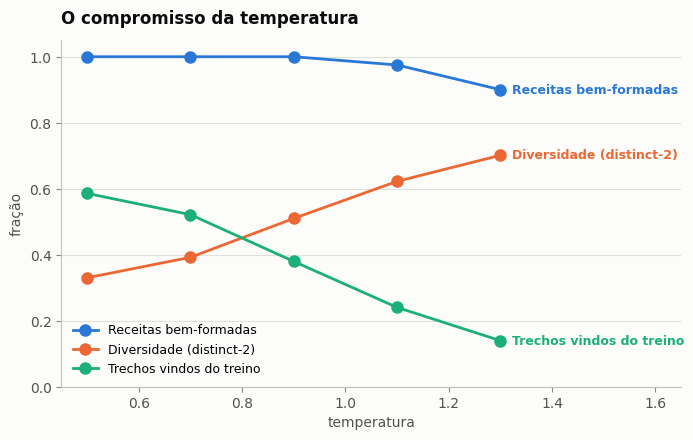

             bem_formadas  distinct_2  taxa_copia
temperatura                                      
0.5                 1.000       0.330       0.586
0.7                 1.000       0.392       0.521
0.9                 1.000       0.510       0.380
1.1                 0.975       0.622       0.240
1.3                 0.900       0.701       0.140


In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))

series = [
    ("bem_formadas", "Receitas bem-formadas", AZUL),
    ("distinct_2", "Diversidade (distinct-2)", LARANJA),
    ("taxa_copia", "Trechos vindos do treino", AQUA),
]
for coluna, rotulo, cor in series:
    ax.plot(resumo.index, resumo[coluna], marker="o", color=cor, label=rotulo)
    # Rótulo direto no último ponto: identidade não depende só da cor.
    ax.annotate(
        rotulo, (resumo.index[-1], resumo[coluna].iloc[-1]),
        xytext=(8, 0), textcoords="offset points",
        color=cor, fontsize=9, fontweight="bold", va="center",
    )

ax.set_title("O compromisso da temperatura")
ax.set_xlabel("temperatura")
ax.set_ylabel("fração")
ax.set_ylim(0, 1.05)
ax.set_xlim(min(TEMPERATURAS) - 0.05, max(TEMPERATURAS) + 0.35)
ax.legend(loc="lower left")
plt.savefig(FIGURAS / "03_temperatura.png")
plt.show()

print(resumo[["bem_formadas", "distinct_2", "taxa_copia"]].round(3).to_string())

### Qual o pior caso de cópia?

A taxa média esconde os extremos. Aqui se procura o maior trecho literal em
todas as gerações — se aparecer uma receita inteira recortada, é sinal de
sobreajuste e o treino precisa de menos épocas.

In [9]:
piores = []
for temperatura, receitas in geracoes.items():
    for receita in receitas:
        piores.append((maior_trecho_copiado(receita.texto_bruto, corpus_tokens), temperatura, receita))

piores.sort(key=lambda x: -x[0])
tamanho, temperatura, pior = piores[0]

print(f"maior trecho contíguo copiado do treino: {tamanho} palavras (temperatura {temperatura})")
print(f"mediana entre todas as gerações: {pd.Series([p[0] for p in piores]).median():.0f} palavras\n")
print(pior.texto_bruto[:600])

maior trecho contíguo copiado do treino: 20 palavras (temperatura 0.5)
mediana entre todas as gerações: 10 palavras

MODO: por-titulo
CATEGORIA: Pudins
TÍTULO: Pudim de leite condensado
INGREDIENTES:
- 1 lata de leite condensado
- 1 lata de leite em pó (medir na lata acima)
PREPARO:
1. Misture bem todos os ingredientes e leve ao fogo baixo para engrossar
2. Quando começar a ferver, bata o leite condensado no liquidificador até ficar cremoso
3. Despeje em fôrma untada e asse em forno quente


## 4. Diversidade — o modelo repete a si mesmo?

Originalidade em relação ao treino não garante variedade interna: o modelo pode
inventar uma receita nova e depois gerá-la sempre igual. A similaridade de
Jaccard entre pares de amostras mede isso.

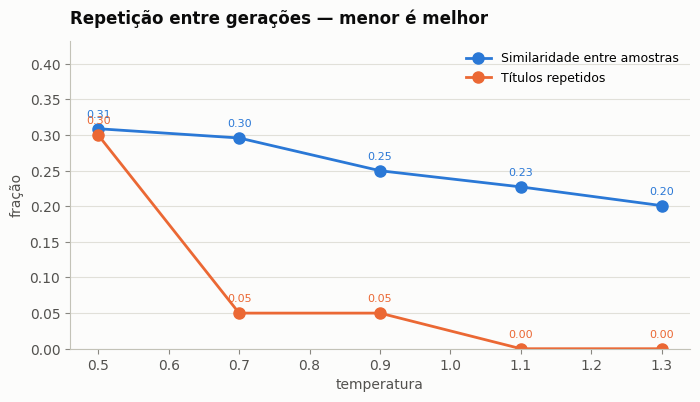

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(resumo.index, resumo["repeticao"], marker="o", color=AZUL, label="Similaridade entre amostras")
ax.plot(resumo.index, resumo["titulos_repetidos"], marker="o", color=LARANJA, label="Títulos repetidos")
for coluna, cor in [("repeticao", AZUL), ("titulos_repetidos", LARANJA)]:
    for x, y in zip(resumo.index, resumo[coluna]):
        ax.annotate(f"{y:.2f}", (x, y), xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=8, color=cor)

ax.set_title("Repetição entre gerações — menor é melhor")
ax.set_xlabel("temperatura")
ax.set_ylabel("fração")
ax.set_ylim(0, max(resumo[["repeticao", "titulos_repetidos"]].max()) * 1.4)
ax.legend()
plt.savefig(FIGURAS / "03_diversidade.png")
plt.show()

## 5. Estrutura — a saída é utilizável?

A métrica mais próxima da experiência real de quem usa o playground: a geração
tem título, pelo menos dois ingredientes e pelo menos um passo de preparo?

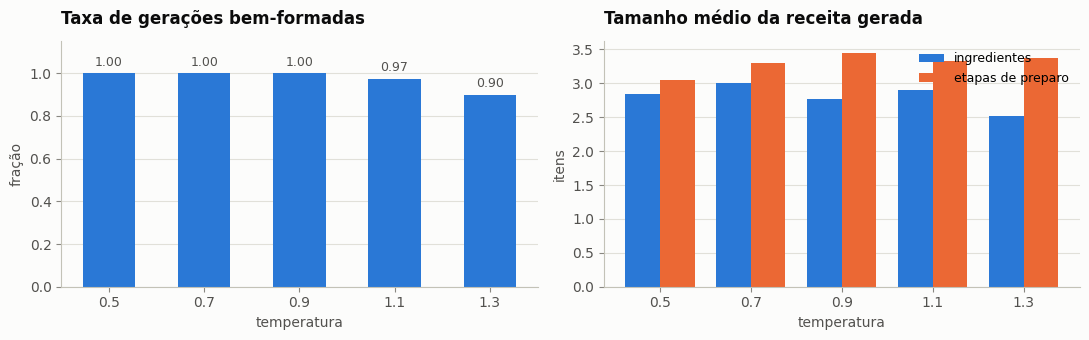

corpus real: 6.6 ingredientes e 5.5 etapas em média


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

ax1.bar(resumo.index.astype(str), resumo["bem_formadas"], color=AZUL, width=0.55)
rotular_barras(ax1, formato="{:.2f}")
ax1.set_title("Taxa de gerações bem-formadas")
ax1.set_xlabel("temperatura")
ax1.set_ylabel("fração")
ax1.set_ylim(0, 1.15)

largura = 0.38
posicoes = range(len(resumo))
ax2.bar([p - largura / 2 for p in posicoes], resumo["media_ingredientes"],
        width=largura, color=AZUL, label="ingredientes")
ax2.bar([p + largura / 2 for p in posicoes], resumo["media_passos"],
        width=largura, color=LARANJA, label="etapas de preparo")
ax2.set_xticks(list(posicoes), resumo.index.astype(str))
ax2.set_title("Tamanho médio da receita gerada")
ax2.set_xlabel("temperatura")
ax2.set_ylabel("itens")
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURAS / "03_estrutura.png")
plt.show()

# Referência: como são as receitas reais do corpus.
reais_ing = pd.Series([len(r["ingredientes"]) for r in receitas_originais]).mean()
reais_passos = pd.Series([len(r["preparo"]) for r in receitas_originais]).mean()
print(f"corpus real: {reais_ing:.1f} ingredientes e {reais_passos:.1f} etapas em média")

## 6. Leitura qualitativa

Métrica nenhuma substitui ler o que saiu. Três receitas em temperaturas
diferentes, lado a lado.

In [12]:
from tech_challenge_fase_04.modelo.geracao import formatar_para_leitura

for temperatura in [0.5, 0.9, 1.3]:
    exemplo = next(r for r in geracoes[temperatura] if r.bem_formada)
    copia = taxa_de_copia(exemplo.texto_bruto, indice_treino)
    print("=" * 70)
    print(f"TEMPERATURA {temperatura}  |  cópia do treino: {copia:.0%}")
    print("=" * 70)
    print(formatar_para_leitura(exemplo))
    print()

TEMPERATURA 0.5  |  cópia do treino: 41%
## Massa de porco assado
*Carnes*

**Ingredientes**

- 1 kg de carne moída, cortada em pedaços pequenos
- 1 colher (sopa) rasa de sal
- 1/2 kg de carne bovina picada e passada no liquidificador

**Modo de preparo**

1. Misture tudo até obter uma massa homogênea
2. Acrescente o queijo ralado, a farinha de trigo e o sal
3. Leve ao forno preaquecido para assar

TEMPERATURA 0.9  |  cópia do treino: 12%
## Massa de porco frito à Bomjepe
*Carnes*

**Ingredientes**

- 1 e 1/2 xícaras (chá) de manteiga
- 1 colherinha de sal
- 4 ovos batidos com um pouco mais leite e sem sementes, picadas

**Modo de preparo**

1. Bata a manteiga em óleo bem quente e junte os demais ingredientes aos poucos até obter uma massa mole
2. Acrescente o leite, bate bem e deixe crescer
3. Junte as gemas batidas na batedeira, misture bem
4. Em seguida, coloque numa assadeira untada com manteiga ou com manteiga gelatina, para empelotar
5. Ponha queijo parmesão ralado
6. Se quiser n

## 7. Conclusão — parâmetros escolhidos

Preencha a tabela abaixo com os números que saíram na sua execução; ela é o
resumo que vai para o vídeo.

| Temperatura | Bem-formadas | Diversidade | Cópia do treino | Leitura |
|---|---|---|---|---|
| 0,5 | | | | conservador, tende a repetir |
| 0,9 | | | | equilíbrio |
| 1,3 | | | | criativo, mais erros |

**Padrão adotado no playground:** `temperature=0.9`, `top_p=0.92`, `top_k=50`,
`repetition_penalty=1.15` — o ponto em que a taxa de bem-formadas ainda é alta
sem que a diversidade despenque. Os controles ficam expostos na barra lateral
justamente para que quem avalia possa percorrer essa fronteira.

In [13]:
resumo.round(3).to_csv(RAIZ / "reports" / "avaliacao_temperatura.csv")
print("resumo salvo em reports/avaliacao_temperatura.csv")
resumo.round(3)

resumo salvo em reports/avaliacao_temperatura.csv


,taxa_copia,distinct_2,bem_formadas,repeticao,titulos_repetidos,media_ingredientes,media_passos
temperatura,,,,,,,
0.5,0.586,0.330,1.000,0.309,0.30,2.850,3.050
0.7,0.521,0.392,1.000,0.296,0.05,3.000,3.300
0.9,0.380,0.510,1.000,0.250,0.05,2.775,3.450
1.1,0.240,0.622,0.975,0.227,0.00,2.900,3.325
1.3,0.140,0.701,0.900,0.201,0.00,2.525,3.375
